# AI vs. Human data-journalism artifacts — review study analysis

Each participant scored a **paired** Version A and Version B of an artifact on the five rubric dimensions (Visual Design, Narrative & Pacing, Data & Method Transparency, Claim–Data Alignment, Insight Value), then gave an overall preference. The columns `version_a_type` and `version_b_type` tell us which side was AI-generated and which was human-generated.

Below we:
1. Clean the export and extract the 1–7 integer scores.
2. Re-label every score by *source* (AI vs. human) using the per-row assignment.
3. Compare AI and human on each dimension (means, paired differences, significance).
4. Look at the overall preference question (`pair_q1`).
5. Break results down per artifact pair.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CSV_PATH = Path("Data Journalist_May 4, 2026_21.37.csv")

raw = pd.read_csv(CSV_PATH, skiprows=[1, 2])
df_all = raw[raw["Status"] == "IP Address"].copy()
df_all = df_all[df_all["version_a_type"].notna()].copy()
print(f"Real participant rows (pre-filter): {len(df_all)}")
df_all[["pair_id", "version_a_type", "version_b_type", "panel_condition_a", "panel_condition_b"]].head()

Real participant rows (pre-filter): 58


,pair_id,version_a_type,version_b_type,panel_condition_a,panel_condition_b
3,P5AB,ai,human,enabled,not present
4,E5BA,human,ai,not present,enabled
5,E4BA,human,ai,not present,enabled
6,P5AB,ai,human,enabled,not present
7,T6BA,human,ai,not present,enabled


## 1a. Filter out low-quality responses

Before any analysis we drop participants who clearly didn't complete the task in good faith. The study asks reviewers to read two artifacts in full, score five rubric dimensions on each, and write a 2–4 sentence justification for every score. We flag a row as low quality if it fails **any** of:

| Filter | Threshold | What it catches |
|---|---|---|
| `total_too_short` | total `Duration` < 300 s (5 min) | speed-runs |
| `page_too_short` | either artifact's page-submit time < 60 s | did not actually open / read one of the two artifacts |
| `too_many_missing_scores` | ≥ 2 of the 10 dimension scores missing | abandoned scoring |
| `empty_justifications` | mean justification length across the 10 free-text boxes < 30 chars | scored without writing reasons |

Each criterion is logged separately so we can see *why* a row was dropped, and the filter is conservative: it removes only responses that fail at least one of these basic engagement checks.

In [2]:
def _parse_int(value):
    if pd.isna(value):
        return np.nan
    m = re.match(r"\s*(\d+)", str(value))
    return int(m.group(1)) if m else np.nan

_score_a = pd.DataFrame({f"d{d}": df_all[f"D{d}A"].map(_parse_int) for d in range(1, 6)})
_score_b = pd.DataFrame({f"d{d}": df_all[f"D{d}B"].map(_parse_int) for d in range(1, 6)})
_just_cols = [f"D{d}{s}r" for s in ("A", "B") for d in range(1, 6)]
_just_lens = df_all[_just_cols].fillna("").astype(str).applymap(len)

quality = pd.DataFrame({
    "ResponseId": df_all["ResponseId"].values,
    "duration_s": df_all["Duration (in seconds)"].astype(float).values,
    "page_A_s": df_all["Timing_Page Submit.1"].astype(float).values,
    "page_B_s": df_all["Timing_Page Submit.2"].astype(float).values,
    "n_missing_scores": (_score_a.isna().sum(axis=1) + _score_b.isna().sum(axis=1)).values,
    "mean_just_len": _just_lens.mean(axis=1).values,
})

MIN_DURATION_S = 300
MIN_PAGE_S = 60
MAX_MISSING_SCORES = 1
MIN_MEAN_JUST_LEN = 30

quality["total_too_short"] = quality["duration_s"] < MIN_DURATION_S
quality["page_too_short"] = (quality["page_A_s"] < MIN_PAGE_S) | (quality["page_B_s"] < MIN_PAGE_S)
quality["too_many_missing_scores"] = quality["n_missing_scores"] > MAX_MISSING_SCORES
quality["empty_justifications"] = quality["mean_just_len"] < MIN_MEAN_JUST_LEN

flag_cols = ["total_too_short", "page_too_short", "too_many_missing_scores", "empty_justifications"]
quality["low_quality"] = quality[flag_cols].any(axis=1)

print(f"Filter trip counts (a row may trip more than one):")
for c in flag_cols:
    print(f"  {c:28s}: {int(quality[c].sum())}")

n_before = len(quality)
n_drop = int(quality["low_quality"].sum())
n_after = n_before - n_drop
print(f"\nDropping {n_drop} of {n_before} responses ({n_drop / n_before * 100:.1f}%) → {n_after} kept")

print("\nDropped rows (with the flags they tripped):")
dropped = quality[quality["low_quality"]].copy()
dropped["why"] = dropped[flag_cols].apply(
    lambda r: ", ".join(c for c in flag_cols if r[c]), axis=1)
display_cols = ["ResponseId", "duration_s", "page_A_s", "page_B_s",
                "n_missing_scores", "mean_just_len", "why"]
dropped[display_cols].sort_values("duration_s").round(1)

Filter trip counts (a row may trip more than one):
  total_too_short             : 4
  page_too_short              : 6
  too_many_missing_scores     : 4
  empty_justifications        : 8

Dropping 8 of 58 responses (13.8%) → 50 kept

Dropped rows (with the flags they tripped):


,ResponseId,duration_s,page_A_s,page_B_s,n_missing_scores,mean_just_len,why
3,R_5yecEnPZvU6zvA8,15.0,1.9,2.3,10,0.0,"total_too_short, page_too_short, too_many_miss..."
2,R_7iqkAXKNXZNuEkx,22.0,7.8,2.2,8,0.0,"total_too_short, page_too_short, too_many_miss..."
1,R_5rJor4lLllQ1CFM,31.0,9.0,3.6,10,0.0,"total_too_short, page_too_short, too_many_miss..."
0,R_7q7zxODgKDWnAoK,42.0,2.2,2.1,10,0.0,"total_too_short, page_too_short, too_many_miss..."
30,R_8OrmDSEfqojO67D,556.0,55.1,19.0,0,0.0,"page_too_short, empty_justifications"
4,R_8sFaHVpxbEEbOKZ,1528.0,659.1,244.8,0,16.8,empty_justifications
39,R_2qVBmiy5dgmgyFh,1607.0,418.3,54.1,0,17.0,"page_too_short, empty_justifications"
10,R_8PXm3uVisosllnx,2055.0,157.3,121.6,0,0.0,empty_justifications


In [3]:
good_ids = quality.loc[~quality["low_quality"], "ResponseId"].tolist()
df = df_all[df_all["ResponseId"].isin(good_ids)].copy()
print(f"Analysis-grade rows: {len(df)} (was {len(df_all)})")
df[["pair_id", "version_a_type", "version_b_type", "panel_condition_a", "panel_condition_b"]].head()

Analysis-grade rows: 50 (was 58)


,pair_id,version_a_type,version_b_type,panel_condition_a,panel_condition_b
8,P5BA,human,ai,not present,enabled
9,P3AB,ai,human,enabled,not present
10,E1AB,ai,human,enabled,not present
11,E6BA,human,ai,not present,enabled
12,T5AB,human,ai,not present,enabled


## 1. Extract integer scores and re-label by source

The dimension cells store the full anchor text (e.g. `"4 — Polished but with two or three…"`). We pull the leading integer. Then, for each participant, we map their A/B scores to **AI** and **Human** scores using `version_a_type` / `version_b_type`.

In [4]:
DIM_LABELS = {
    1: "Visual Design",
    2: "Narrative & Pacing",
    3: "Data & Method Transparency",
    4: "Claim–Data Alignment",
    5: "Insight Value",
}

def parse_score(value):
    if pd.isna(value):
        return np.nan
    m = re.match(r"\s*(\d+)", str(value))
    return int(m.group(1)) if m else np.nan

for side in ("A", "B"):
    for d in range(1, 6):
        df[f"score_{side}_d{d}"] = df[f"D{d}{side}"].map(parse_score)

records = []
for _, row in df.iterrows():
    a_type = row["version_a_type"]
    b_type = row["version_b_type"]
    if pd.isna(a_type) or pd.isna(b_type):
        continue
    rec = {
        "response_id": row["ResponseId"],
        "pair_id": row["pair_id"],
        "panel_condition_ai": row["panel_condition_a"] if a_type == "ai" else row["panel_condition_b"],
        "panel_condition_human": row["panel_condition_a"] if a_type == "human" else row["panel_condition_b"],
    }
    for d in range(1, 6):
        a_val = row[f"score_A_d{d}"]
        b_val = row[f"score_B_d{d}"]
        rec[f"ai_d{d}"] = a_val if a_type == "ai" else b_val
        rec[f"human_d{d}"] = a_val if a_type == "human" else b_val
    records.append(rec)

paired = pd.DataFrame(records)
print(f"Paired rows: {len(paired)}")
paired.head()

Paired rows: 50


,response_id,pair_id,panel_condition_ai,panel_condition_human,ai_d1,human_d1,ai_d2,human_d2,ai_d3,human_d3,ai_d4,human_d4,ai_d5,human_d5
0,R_2fGC6BdhIKTWlr2,P5BA,enabled,not present,3,3,3,3,5,3,3.0,NaN,3.0,3.0
1,R_7mwVtjRNOQEBuns,P3AB,enabled,not present,5,6,6,5,6,6,5.0,5.0,4.0,4.0
2,R_2f2xJmAyS7aHmgE,E1AB,enabled,not present,4,3,5,4,4,3,5.0,4.0,5.0,4.0
3,R_2CEjpzDFopn5TNL,E6BA,enabled,not present,5,4,6,4,2,2,5.0,3.0,5.0,4.0
4,R_6PcL0kviOTIHTm8,T5AB,enabled,not present,6,5,5,4,6,3,7.0,6.0,5.0,5.0


## 2. Mean score per dimension — AI vs. Human

For each of the 5 rubric dimensions we compute mean ± SE across participants, separately for AI-generated and human-generated artifacts.

In [5]:
summary_rows = []
for d in range(1, 6):
    ai = paired[f"ai_d{d}"].dropna()
    hu = paired[f"human_d{d}"].dropna()
    pair_df = paired[[f"ai_d{d}", f"human_d{d}"]].dropna()
    diffs = pair_df[f"ai_d{d}"] - pair_df[f"human_d{d}"]
    t_stat, t_p = stats.ttest_rel(pair_df[f"ai_d{d}"], pair_df[f"human_d{d}"]) if len(pair_df) > 1 else (np.nan, np.nan)
    try:
        w_stat, w_p = stats.wilcoxon(pair_df[f"ai_d{d}"], pair_df[f"human_d{d}"], zero_method="wilcox")
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    summary_rows.append({
        "dimension": DIM_LABELS[d],
        "n_ai": len(ai),
        "ai_mean": ai.mean(),
        "ai_se": ai.std(ddof=1) / np.sqrt(len(ai)) if len(ai) else np.nan,
        "n_human": len(hu),
        "human_mean": hu.mean(),
        "human_se": hu.std(ddof=1) / np.sqrt(len(hu)) if len(hu) else np.nan,
        "n_paired": len(pair_df),
        "mean_diff_ai_minus_human": diffs.mean(),
        "paired_t_p": t_p,
        "wilcoxon_p": w_p,
    })

summary = pd.DataFrame(summary_rows).set_index("dimension")
summary.round(3)

/Users/batuel/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/batuel/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/batuel/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/batuel/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.w

,n_ai,ai_mean,ai_se,n_human,human_mean,human_se,n_paired,mean_diff_ai_minus_human,paired_t_p,wilcoxon_p
dimension,,,,,,,,,,
Visual Design,50,4.160,0.167,50,3.720,0.164,50,0.440,0.038,0.027
Narrative & Pacing,50,4.080,0.191,50,3.260,0.164,50,0.820,0.000,0.000
Data & Method Transparency,50,4.400,0.190,50,3.000,0.174,50,1.400,0.000,0.000
Claim–Data Alignment,50,4.220,0.184,48,3.667,0.172,48,0.562,0.006,0.003
Insight Value,49,3.939,0.169,50,3.420,0.154,49,0.510,0.006,0.006


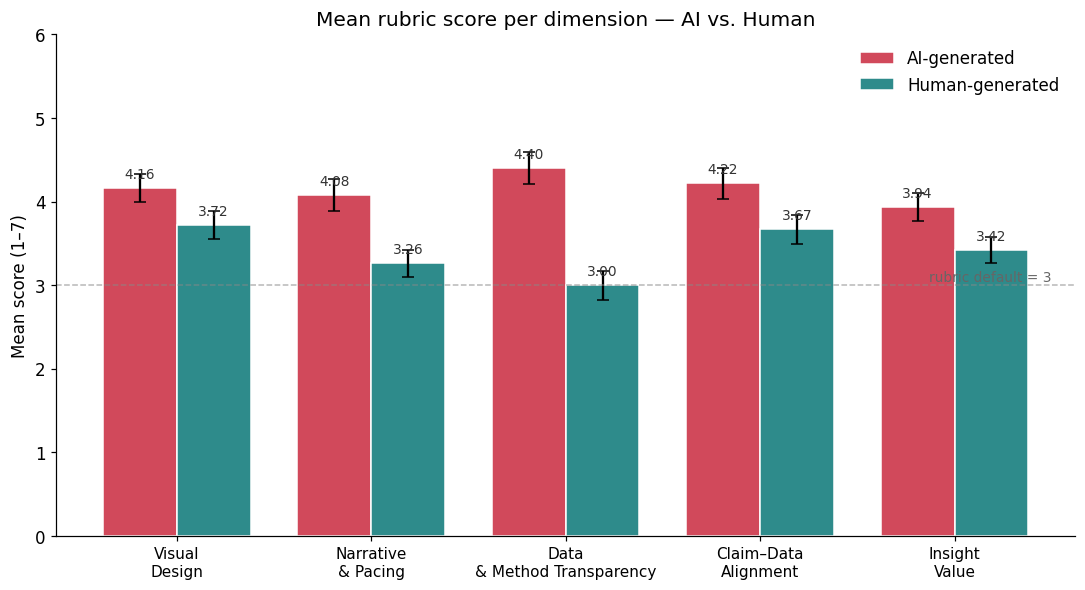

In [6]:
AI_COLOR = "#d1495b"
HUMAN_COLOR = "#2e8b8b"

dims = list(DIM_LABELS.values())
x = np.arange(len(dims))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))
ai_means = summary["ai_mean"].values
hu_means = summary["human_mean"].values
ai_err = summary["ai_se"].values
hu_err = summary["human_se"].values

bars_ai = ax.bar(x - width / 2, ai_means, width, yerr=ai_err, capsize=4,
                 color=AI_COLOR, label="AI-generated", edgecolor="white")
bars_hu = ax.bar(x + width / 2, hu_means, width, yerr=hu_err, capsize=4,
                 color=HUMAN_COLOR, label="Human-generated", edgecolor="white")

for bars, vals in [(bars_ai, ai_means), (bars_hu, hu_means)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.08, f"{v:.2f}",
                ha="center", va="bottom", fontsize=9, color="#333")

ax.axhline(3, linestyle="--", color="#888", linewidth=1, alpha=0.6)
ax.text(len(dims) - 0.5, 3.05, "rubric default = 3", color="#666", fontsize=9, ha="right")

ax.set_xticks(x)
ax.set_xticklabels([d.replace(" ", "\n", 1) for d in dims], fontsize=10)
ax.set_ylabel("Mean score (1–7)")
ax.set_ylim(0, 6)
ax.set_title("Mean rubric score per dimension — AI vs. Human")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

## 3. Paired differences (AI − Human) per dimension

Because every reviewer scored both sides, the cleanest comparison is **within-reviewer differences**. Positive ⇒ AI scored higher than the human artifact that this same reviewer also saw; negative ⇒ human scored higher.

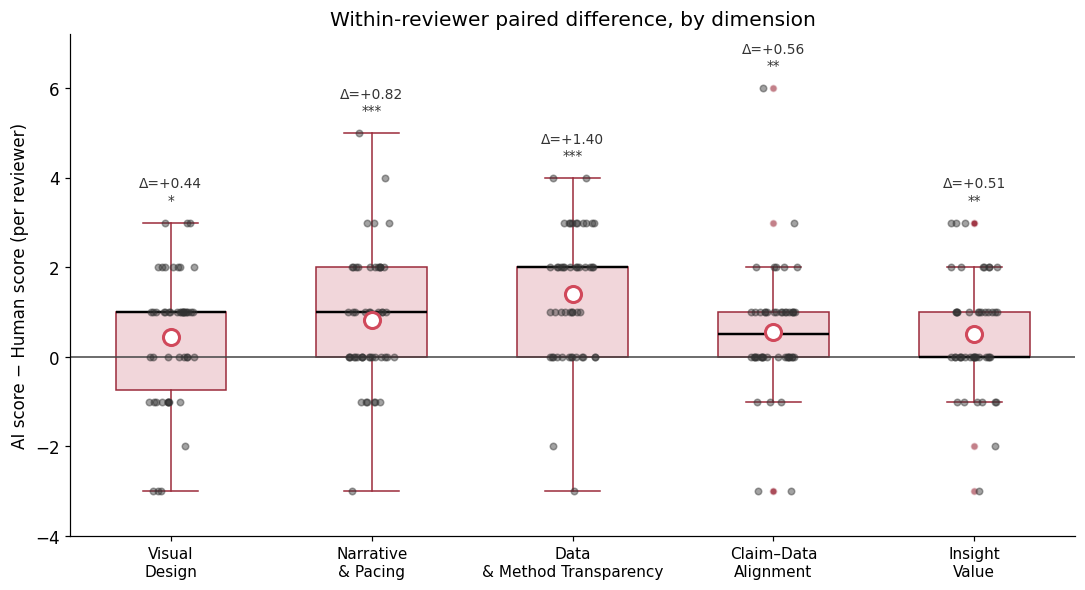

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
diff_data = []
for d in range(1, 6):
    pair_df = paired[[f"ai_d{d}", f"human_d{d}"]].dropna()
    diff_data.append((pair_df[f"ai_d{d}"] - pair_df[f"human_d{d}"]).values)

bp = ax.boxplot(
    diff_data, positions=range(1, 6), widths=0.55, patch_artist=True,
    medianprops=dict(color="black", linewidth=1.6),
    boxprops=dict(facecolor="#f1d6da", edgecolor="#9b2b3b"),
    whiskerprops=dict(color="#9b2b3b"),
    capprops=dict(color="#9b2b3b"),
    flierprops=dict(marker="o", markerfacecolor="#9b2b3b", markeredgecolor="white", markersize=5, alpha=0.6),
)

rng = np.random.default_rng(42)
for i, vals in enumerate(diff_data, start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
               color="#333", alpha=0.45, s=18, zorder=3)

for i, vals in enumerate(diff_data, start=1):
    mean_diff = np.mean(vals)
    ax.scatter([i], [mean_diff], color="white", edgecolor=AI_COLOR, s=110, zorder=4, linewidth=2)
    p = summary.iloc[i - 1]["paired_t_p"]
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(i, max(vals) + 0.35, f"Δ={mean_diff:+.2f}\n{star}",
            ha="center", va="bottom", fontsize=9, color="#333")

ax.axhline(0, color="#444", linewidth=1)
ax.set_xticks(range(1, 6))
ax.set_xticklabels([d.replace(" ", "\n", 1) for d in dims], fontsize=10)
ax.set_ylabel("AI score − Human score (per reviewer)")
ax.set_title("Within-reviewer paired difference, by dimension")
ax.set_ylim(min(min(v) for v in diff_data) - 1, max(max(v) for v in diff_data) + 1.2)
fig.tight_layout()
plt.show()

## 4. Score distributions per dimension

The bar/box charts show averages, but the rubric scale is discrete (1–7) and the rubric explicitly says *"3 is the typical score."* Here we show **how the full distribution shifts** between AI and human artifacts on each dimension.

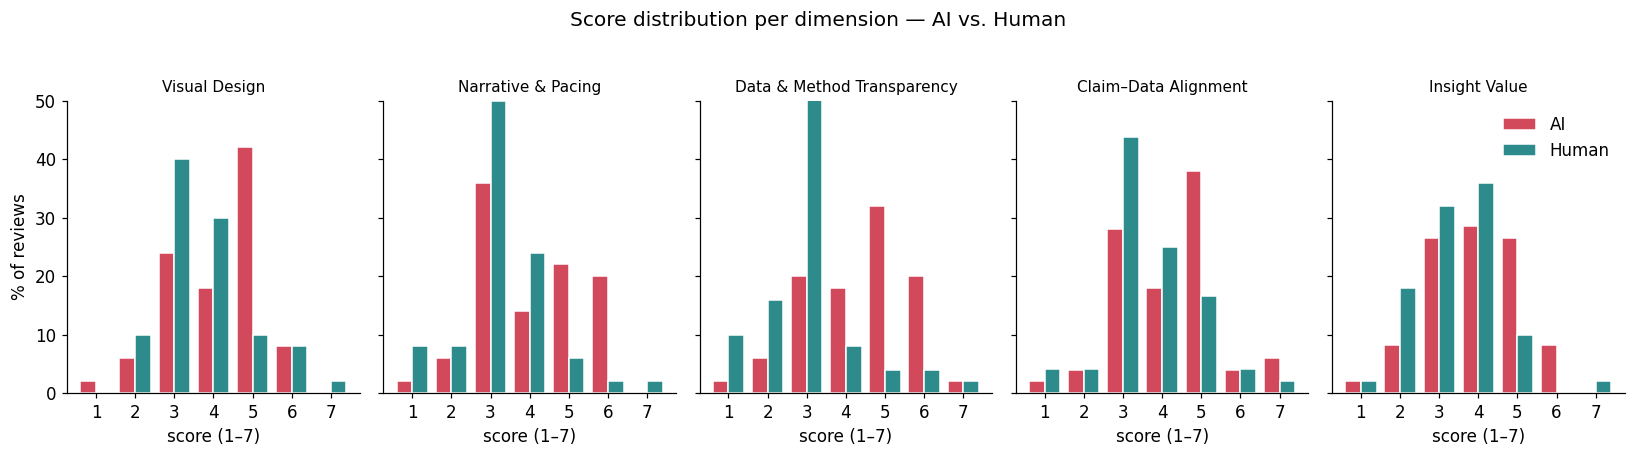

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=True)
score_levels = np.arange(1, 8)
bw = 0.4

for d, ax in zip(range(1, 6), axes):
    ai = paired[f"ai_d{d}"].dropna().astype(int)
    hu = paired[f"human_d{d}"].dropna().astype(int)
    ai_pct = np.array([(ai == s).sum() / len(ai) * 100 if len(ai) else 0 for s in score_levels])
    hu_pct = np.array([(hu == s).sum() / len(hu) * 100 if len(hu) else 0 for s in score_levels])
    ax.bar(score_levels - bw / 2, ai_pct, bw, color=AI_COLOR, label="AI", edgecolor="white")
    ax.bar(score_levels + bw / 2, hu_pct, bw, color=HUMAN_COLOR, label="Human", edgecolor="white")
    ax.set_title(DIM_LABELS[d], fontsize=10)
    ax.set_xticks(score_levels)
    ax.set_xlabel("score (1–7)")
    if d == 1:
        ax.set_ylabel("% of reviews")
    ax.set_ylim(0, max(ai_pct.max(), hu_pct.max()) * 1.25 + 5)

axes[-1].legend(frameon=False, loc="upper right")
fig.suptitle("Score distribution per dimension — AI vs. Human", y=1.03)
fig.tight_layout()
plt.show()

## 5. Overall preference question (`pair_q1`)

After scoring both versions, each reviewer answered which one was stronger on a 5-point scale. We translate this from `Version A/B` language into AI/Human language using each row's assignment.

In [9]:
PAIR_Q1_TO_A_PREF = {
    "Version A is much stronger": 2,
    "Version A is somewhat stronger": 1,
    "The two are roughly equivalent": 0,
    "Version B is somewhat stronger": -1,
    "Version B is much stronger": -2,
}

pref_records = []
for _, row in df.iterrows():
    raw_pref = row["pair_q1"]
    if pd.isna(raw_pref) or raw_pref not in PAIR_Q1_TO_A_PREF:
        continue
    a_pref = PAIR_Q1_TO_A_PREF[raw_pref]
    a_type = row["version_a_type"]
    ai_pref = a_pref if a_type == "ai" else -a_pref
    pref_records.append({
        "response_id": row["ResponseId"],
        "pair_id": row["pair_id"],
        "ai_preference": ai_pref,
    })

pref = pd.DataFrame(pref_records)
print(f"Reviewers with overall preference: {len(pref)}")

PREF_LABELS = {
    2: "AI much stronger",
    1: "AI somewhat stronger",
    0: "Roughly equivalent",
    -1: "Human somewhat stronger",
    -2: "Human much stronger",
}
counts = pref["ai_preference"].value_counts().reindex([2, 1, 0, -1, -2], fill_value=0)
counts.index = [PREF_LABELS[v] for v in counts.index]
counts.to_frame("n").assign(pct=lambda x: (x["n"] / x["n"].sum() * 100).round(1))

Reviewers with overall preference: 50


,n,pct
AI much stronger,13,26.0
AI somewhat stronger,23,46.0
Roughly equivalent,1,2.0
Human somewhat stronger,10,20.0
Human much stronger,3,6.0


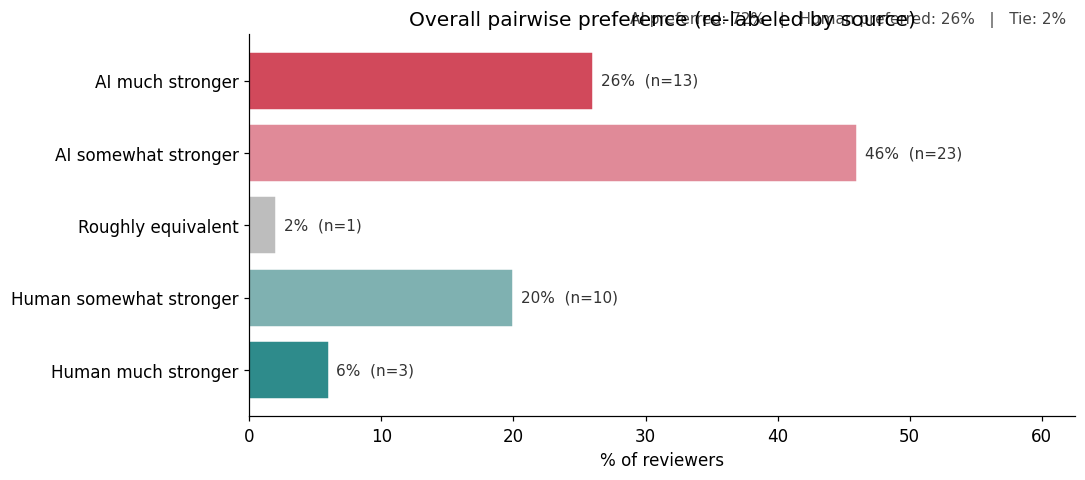

In [10]:
order = [-2, -1, 0, 1, 2]
labels = [PREF_LABELS[v] for v in order]
values = [(pref["ai_preference"] == v).sum() for v in order]
pcts = [v / sum(values) * 100 for v in values]
colors = [HUMAN_COLOR, "#7fb1b1", "#bdbdbd", "#e08a98", AI_COLOR]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(labels, pcts, color=colors, edgecolor="white")
for bar, v, pct in zip(bars, values, pcts):
    ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%  (n={v})", va="center", fontsize=10, color="#333")

ax.set_xlim(0, max(pcts) * 1.25 + 5)
ax.set_xlabel("% of reviewers")
ax.set_title("Overall pairwise preference (re-labeled by source)")

ai_share = sum(values[3:]) / sum(values) * 100
hu_share = sum(values[:2]) / sum(values) * 100
tie_share = values[2] / sum(values) * 100
ax.text(0.99, 1.02, f"AI preferred: {ai_share:.0f}%   |   Human preferred: {hu_share:.0f}%   |   Tie: {tie_share:.0f}%",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10, color="#444")

fig.tight_layout()
plt.show()

## 6. Per-artifact-pair view

Each `pair_id` is a specific (AI artifact, human artifact) duo seen by multiple reviewers. Plotting the average AI–Human gap per pair lets us see whether the overall result is driven by a few pairs or shared across all of them.

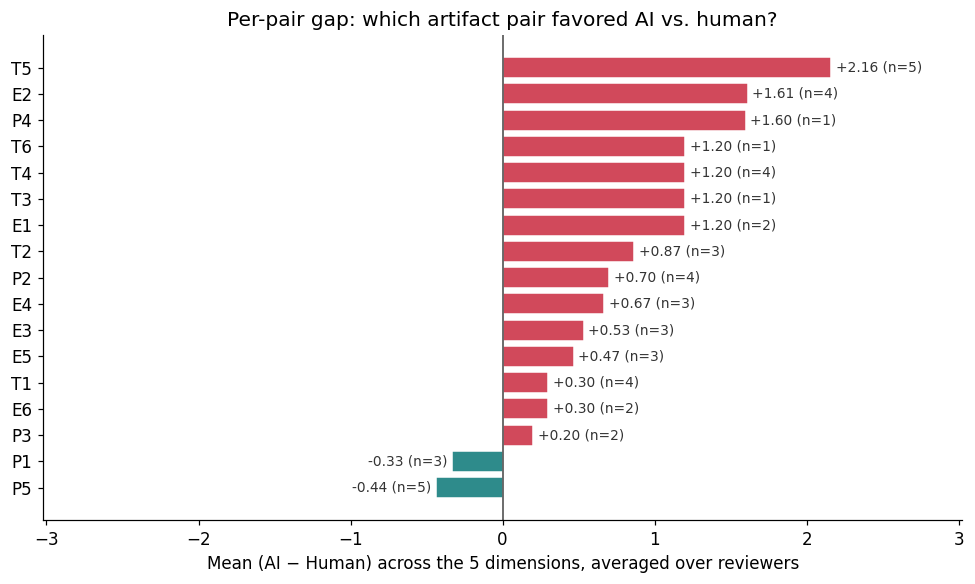

In [11]:
paired["ai_total"] = paired[[f"ai_d{d}" for d in range(1, 6)]].mean(axis=1)
paired["human_total"] = paired[[f"human_d{d}" for d in range(1, 6)]].mean(axis=1)
paired["diff_total"] = paired["ai_total"] - paired["human_total"]

paired["pair_base"] = paired["pair_id"].str.replace(r"(AB|BA)$", "", regex=True)

per_pair = (paired.groupby("pair_base")
                 .agg(ai_mean=("ai_total", "mean"),
                      human_mean=("human_total", "mean"),
                      diff_mean=("diff_total", "mean"),
                      n=("diff_total", "count"))
                 .sort_values("diff_mean"))

fig, ax = plt.subplots(figsize=(9, max(4, len(per_pair) * 0.32)))
colors = [AI_COLOR if v > 0 else HUMAN_COLOR for v in per_pair["diff_mean"]]
ax.barh(per_pair.index, per_pair["diff_mean"], color=colors, edgecolor="white")
ax.axvline(0, color="#444", linewidth=1)
for i, (idx, row) in enumerate(per_pair.iterrows()):
    ax.text(row["diff_mean"] + (0.03 if row["diff_mean"] >= 0 else -0.03),
            i, f"{row['diff_mean']:+.2f} (n={int(row['n'])})",
            ha="left" if row["diff_mean"] >= 0 else "right",
            va="center", fontsize=9, color="#333")

ax.set_xlabel("Mean (AI − Human) across the 5 dimensions, averaged over reviewers")
ax.set_title("Per-pair gap: which artifact pair favored AI vs. human?")
xmax = max(abs(per_pair["diff_mean"].min()), abs(per_pair["diff_mean"].max())) * 1.4
ax.set_xlim(-xmax, xmax)
fig.tight_layout()
plt.show()

### Each artifact pair, one panel

The `pair_id` codes start with **P** (Pew-style), **E** (Economist-style) and **T** (Tabloid/other), giving 5 P-, 6 E-, 6 T-pairs = **17 distinct pairs** in the data (the 30 raw `pair_id` values are just AB / BA orderings of the same 17 pairs). For each pair we plot AI vs. Human across the 5 dimensions; the title shows `n` reviewers and the mean gap (Δ).

Distinct artifact pairs: 17


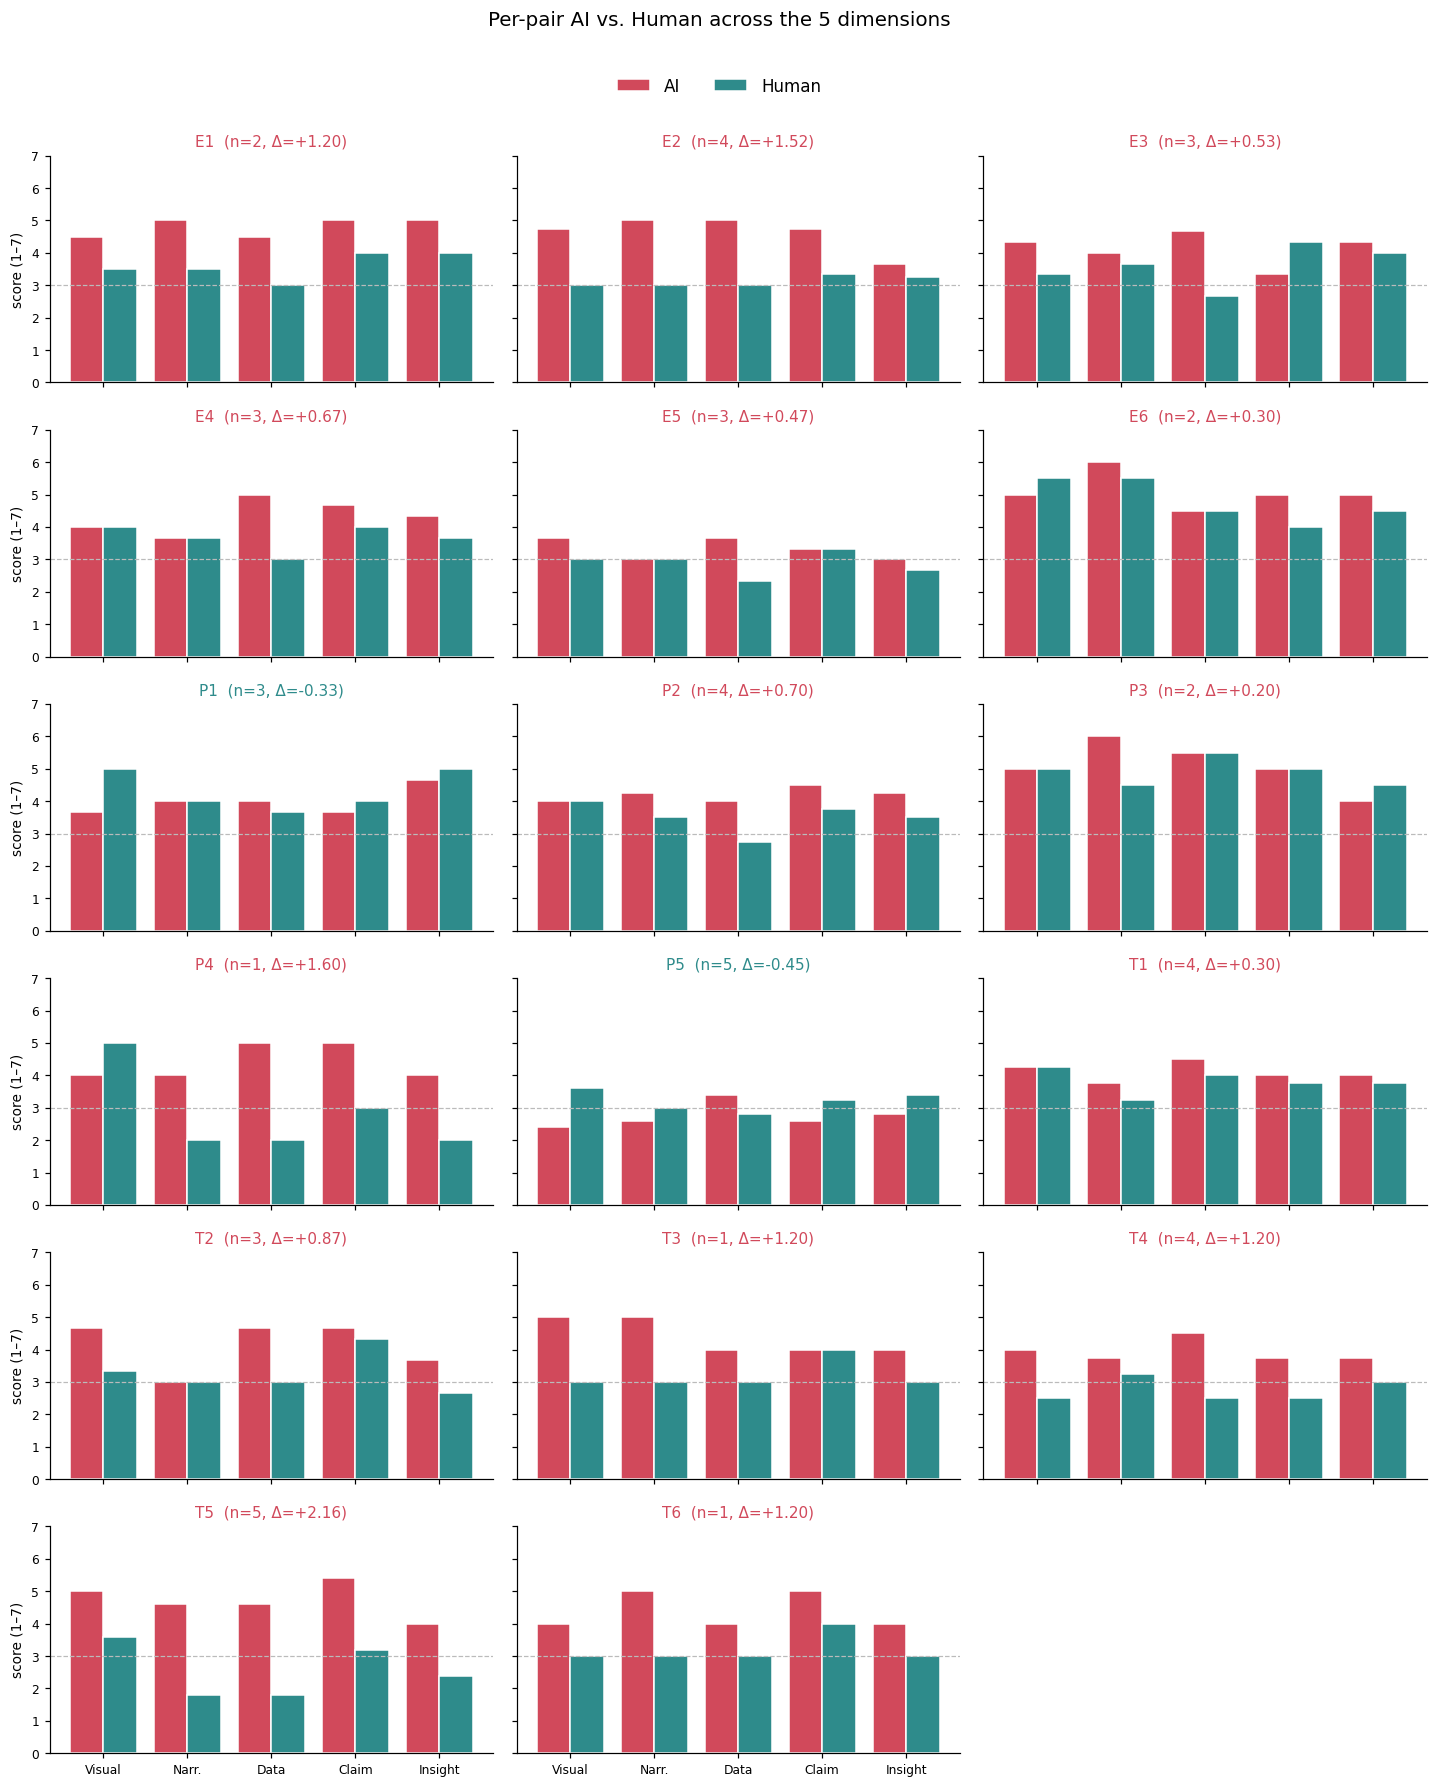

In [12]:
pair_bases = sorted(paired["pair_base"].dropna().unique())
n_pairs = len(pair_bases)
print(f"Distinct artifact pairs: {n_pairs}")

n_cols = 3
n_rows = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.4, n_rows * 2.6),
                         sharey=True, sharex=True)
axes_flat = axes.flatten()

dim_labels_short = ["Visual", "Narr.", "Data", "Claim", "Insight"]
x = np.arange(5)
w = 0.4

for ax, pb in zip(axes_flat, pair_bases):
    sub = paired[paired["pair_base"] == pb]
    ai_means = [sub[f"ai_d{d}"].mean() for d in range(1, 6)]
    hu_means = [sub[f"human_d{d}"].mean() for d in range(1, 6)]
    n = len(sub)
    ax.bar(x - w / 2, ai_means, w, color=AI_COLOR, edgecolor="white", label="AI")
    ax.bar(x + w / 2, hu_means, w, color=HUMAN_COLOR, edgecolor="white", label="Human")
    ax.axhline(3, linestyle="--", color="#bbb", linewidth=0.8)
    overall_diff = np.nanmean(np.array(ai_means) - np.array(hu_means))
    winner_color = AI_COLOR if overall_diff > 0 else HUMAN_COLOR if overall_diff < 0 else "#666"
    ax.set_title(f"{pb}  (n={n}, Δ={overall_diff:+.2f})", fontsize=10, color=winner_color)
    ax.set_xticks(x)
    ax.set_xticklabels(dim_labels_short, fontsize=8, rotation=0)
    ax.set_ylim(0, 7)
    ax.tick_params(axis="y", labelsize=8)

for ax in axes_flat[n_pairs:]:
    ax.set_visible(False)

for r in range(n_rows):
    axes[r, 0].set_ylabel("score (1–7)", fontsize=9)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Per-pair AI vs. Human across the 5 dimensions", y=1.04, fontsize=13)
fig.tight_layout()
plt.show()

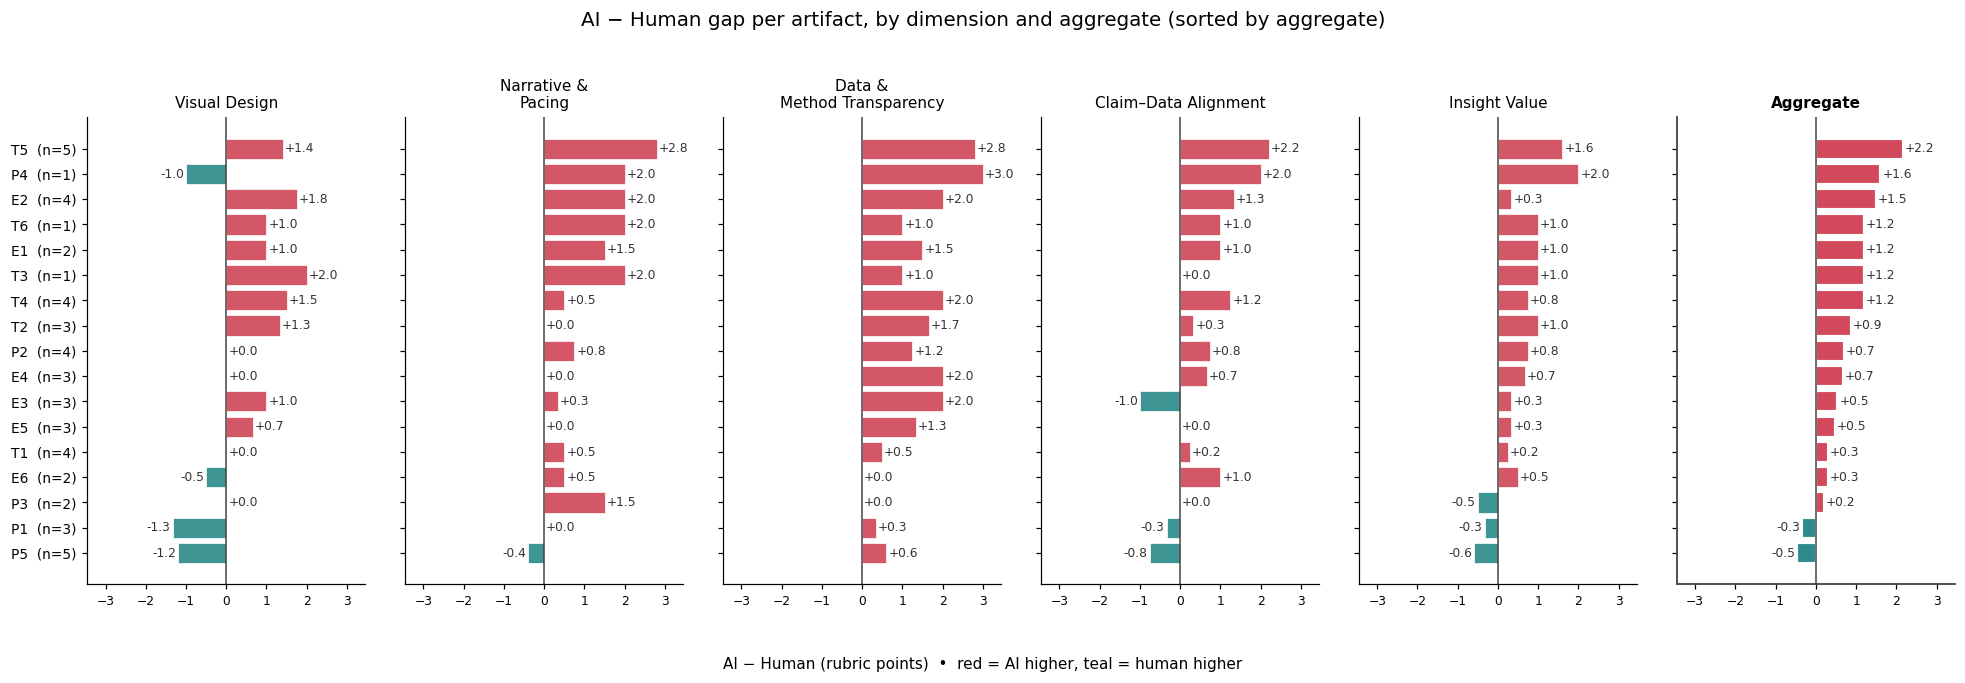

In [13]:
per_pair_dim = {}
for pb in pair_bases:
    sub = paired[paired["pair_base"] == pb]
    diffs = [(sub[f"ai_d{d}"] - sub[f"human_d{d}"]).mean() for d in range(1, 6)]
    per_pair_dim[pb] = diffs

pp_df = pd.DataFrame(per_pair_dim, index=[DIM_LABELS[d] for d in range(1, 6)]).T
pp_df["Aggregate"] = pp_df.mean(axis=1)
pp_df["n"] = [len(paired[paired["pair_base"] == pb]) for pb in pp_df.index]
pp_df = pp_df.sort_values("Aggregate", ascending=True)

cols = [DIM_LABELS[d] for d in range(1, 6)] + ["Aggregate"]
y = np.arange(len(pp_df))
y_labels = [f"{pb}  (n={int(n)})" for pb, n in zip(pp_df.index, pp_df["n"])]

fig, axes = plt.subplots(1, 6, figsize=(18, max(5, len(pp_df) * 0.34)),
                         sharey=True)

vmax = max(abs(pp_df[cols].min().min()), abs(pp_df[cols].max().max())) * 1.15

for ax, col in zip(axes, cols):
    vals = pp_df[col].values
    colors = [AI_COLOR if v > 0 else HUMAN_COLOR for v in vals]
    is_agg = col == "Aggregate"
    ax.barh(y, vals, color=colors, edgecolor="white",
            linewidth=1.4 if is_agg else 0.5,
            alpha=1.0 if is_agg else 0.92)
    ax.axvline(0, color="#444", linewidth=1)
    for yi, v in zip(y, vals):
        if np.isnan(v):
            continue
        ax.text(v + (0.05 if v >= 0 else -0.05), yi, f"{v:+.1f}",
                ha="left" if v >= 0 else "right", va="center",
                fontsize=8, color="#333")
    title_weight = "bold" if is_agg else "normal"
    ax.set_title(col.replace(" & ", " &\n").replace(" — ", "\n"),
                 fontsize=10, fontweight=title_weight)
    ax.set_xlim(-vmax, vmax)
    ax.tick_params(axis="x", labelsize=8)
    if is_agg:
        for spine in ax.spines.values():
            spine.set_color("#444")
            spine.set_linewidth(1.2)

axes[0].set_yticks(y)
axes[0].set_yticklabels(y_labels, fontsize=9)
fig.supxlabel("AI − Human (rubric points)  •  red = AI higher, teal = human higher",
              fontsize=10, y=-0.02)
fig.suptitle("AI − Human gap per artifact, by dimension and aggregate (sorted by aggregate)",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

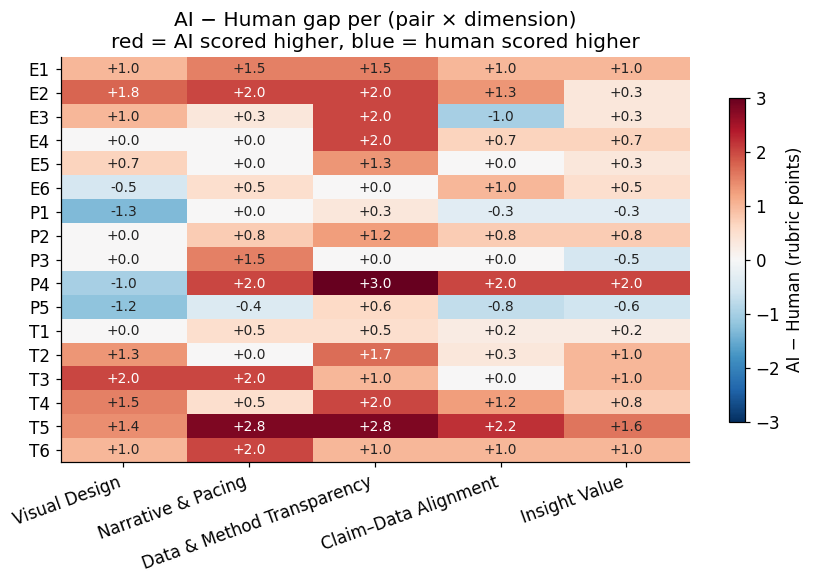

In [14]:
heatmap_rows = []
for pb in pair_bases:
    sub = paired[paired["pair_base"] == pb]
    row = []
    for d in range(1, 6):
        diff = (sub[f"ai_d{d}"] - sub[f"human_d{d}"]).mean()
        row.append(diff)
    heatmap_rows.append(row)

heatmap = np.array(heatmap_rows, dtype=float)

fig, ax = plt.subplots(figsize=(8, max(4.5, n_pairs * 0.32)))
vmax = np.nanmax(np.abs(heatmap))
im = ax.imshow(heatmap, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        v = heatmap[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > vmax * 0.55 else "#222")

ax.set_xticks(range(5))
ax.set_xticklabels([DIM_LABELS[d] for d in range(1, 6)], rotation=20, ha="right")
ax.set_yticks(range(n_pairs))
ax.set_yticklabels(pair_bases)
ax.set_title("AI − Human gap per (pair × dimension)\nred = AI scored higher, blue = human scored higher")
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("AI − Human (rubric points)")
fig.tight_layout()
plt.show()

## Scores by category (E / P / T)

The first letter of each `pair_id` denotes the artifact category:

- **E** — Economist-style (6 pairs)
- **P** — Pew-style (5 pairs)
- **T** — Tabloid / other (6 pairs)

Below we aggregate AI vs. human scores within each category, both overall and per dimension.

In [15]:
CAT_LABELS = {"E": "Economist-style", "P": "Pew-style", "T": "Tabloid / other"}
paired["category"] = paired["pair_base"].str[0]

cat_rows = []
for cat in ["E", "P", "T"]:
    sub = paired[paired["category"] == cat]
    row = {"category": CAT_LABELS[cat], "n_reviews": len(sub),
           "n_pairs": sub["pair_base"].nunique()}
    for d in range(1, 6):
        ai = sub[f"ai_d{d}"].dropna()
        hu = sub[f"human_d{d}"].dropna()
        row[f"AI {DIM_LABELS[d]}"] = ai.mean()
        row[f"Human {DIM_LABELS[d]}"] = hu.mean()
        row[f"Δ {DIM_LABELS[d]}"] = ai.mean() - hu.mean()
    ai_total = sub[[f"ai_d{d}" for d in range(1, 6)]].mean(axis=1).dropna()
    hu_total = sub[[f"human_d{d}" for d in range(1, 6)]].mean(axis=1).dropna()
    row["AI Aggregate"] = ai_total.mean()
    row["Human Aggregate"] = hu_total.mean()
    row["Δ Aggregate"] = ai_total.mean() - hu_total.mean()
    sub_pair = sub[[f"ai_d{d}" for d in range(1, 6)] + [f"human_d{d}" for d in range(1, 6)]].dropna()
    if len(sub_pair) > 1:
        ai_arr = sub_pair[[f"ai_d{d}" for d in range(1, 6)]].mean(axis=1)
        hu_arr = sub_pair[[f"human_d{d}" for d in range(1, 6)]].mean(axis=1)
        t_stat, p = stats.ttest_rel(ai_arr, hu_arr)
        row["paired_t_p (aggregate)"] = p
    cat_rows.append(row)

cat_summary = pd.DataFrame(cat_rows).set_index("category")
cat_summary.round(3)

,n_reviews,n_pairs,AI Visual Design,Human Visual Design,Δ Visual Design,AI Narrative & Pacing,Human Narrative & Pacing,Δ Narrative & Pacing,AI Data & Method Transparency,Human Data & Method Transparency,...,AI Claim–Data Alignment,Human Claim–Data Alignment,Δ Claim–Data Alignment,AI Insight Value,Human Insight Value,Δ Insight Value,AI Aggregate,Human Aggregate,Δ Aggregate,paired_t_p (aggregate)
category,,,,,,,,,,,,,,,,,,,,,
Economist-style,17,6,4.353,3.588,0.765,4.353,3.588,0.765,4.588,3.000,...,4.294,3.812,0.482,4.125,3.588,0.537,4.356,3.506,0.850,0.001
Pew-style,15,5,3.533,4.267,-0.733,3.867,3.467,0.400,4.067,3.267,...,3.800,3.786,0.014,3.800,3.800,0.000,3.813,3.707,0.107,0.772
Tabloid / other,18,6,4.500,3.389,1.111,4.000,2.778,1.222,4.500,2.778,...,4.500,3.444,1.056,3.889,2.944,0.944,4.278,3.067,1.211,0.001


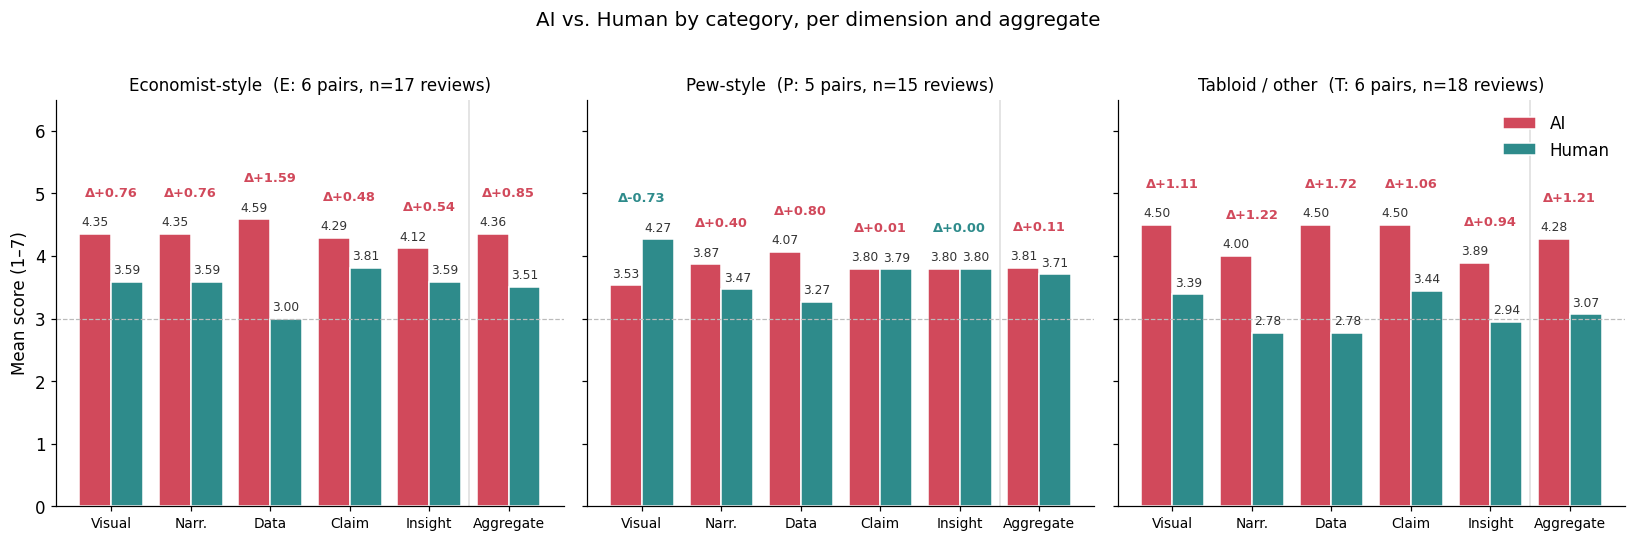

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
dim_short = ["Visual", "Narr.", "Data", "Claim", "Insight", "Aggregate"]
x = np.arange(len(dim_short))
w = 0.4

for ax, cat in zip(axes, ["E", "P", "T"]):
    sub = paired[paired["category"] == cat]
    ai_means = [sub[f"ai_d{d}"].mean() for d in range(1, 6)]
    hu_means = [sub[f"human_d{d}"].mean() for d in range(1, 6)]
    ai_means.append(sub[[f"ai_d{d}" for d in range(1, 6)]].mean(axis=1).mean())
    hu_means.append(sub[[f"human_d{d}" for d in range(1, 6)]].mean(axis=1).mean())

    ax.bar(x - w / 2, ai_means, w, color=AI_COLOR, edgecolor="white", label="AI")
    ax.bar(x + w / 2, hu_means, w, color=HUMAN_COLOR, edgecolor="white", label="Human")

    for xi, (a, h) in enumerate(zip(ai_means, hu_means)):
        ax.text(xi - w / 2, a + 0.08, f"{a:.2f}", ha="center", va="bottom",
                fontsize=8, color="#333")
        ax.text(xi + w / 2, h + 0.08, f"{h:.2f}", ha="center", va="bottom",
                fontsize=8, color="#333")
        diff = a - h
        ax.text(xi, max(a, h) + 0.55, f"Δ{diff:+.2f}",
                ha="center", va="bottom", fontsize=8.5,
                color=AI_COLOR if diff > 0 else HUMAN_COLOR, fontweight="bold")

    ax.axhline(3, linestyle="--", color="#bbb", linewidth=0.8)
    ax.axvline(4.5, color="#ddd", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(dim_short, fontsize=9)
    ax.set_ylim(0, 6.5)
    n_pairs = sub["pair_base"].nunique()
    ax.set_title(f"{CAT_LABELS[cat]}  ({cat}: {n_pairs} pairs, n={len(sub)} reviews)",
                 fontsize=11)

axes[0].set_ylabel("Mean score (1–7)")
axes[-1].legend(frameon=False, loc="upper right")
fig.suptitle("AI vs. Human by category, per dimension and aggregate", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

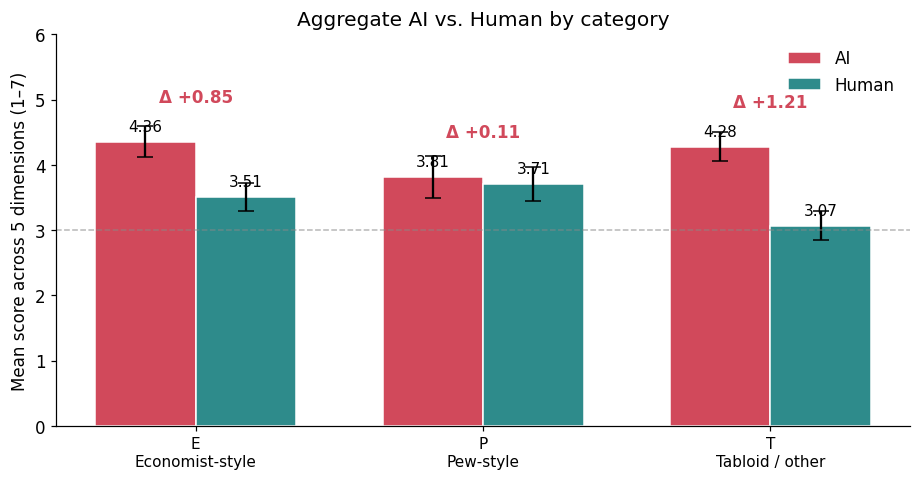

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cat_codes = ["E", "P", "T"]
cat_names = [CAT_LABELS[c] for c in cat_codes]
ai_agg = []
hu_agg = []
ai_se = []
hu_se = []
for cat in cat_codes:
    sub = paired[paired["category"] == cat]
    ai_per_reviewer = sub[[f"ai_d{d}" for d in range(1, 6)]].mean(axis=1).dropna()
    hu_per_reviewer = sub[[f"human_d{d}" for d in range(1, 6)]].mean(axis=1).dropna()
    ai_agg.append(ai_per_reviewer.mean())
    hu_agg.append(hu_per_reviewer.mean())
    ai_se.append(ai_per_reviewer.std(ddof=1) / np.sqrt(len(ai_per_reviewer)))
    hu_se.append(hu_per_reviewer.std(ddof=1) / np.sqrt(len(hu_per_reviewer)))

x = np.arange(len(cat_codes))
w = 0.35
ax.bar(x - w / 2, ai_agg, w, yerr=ai_se, capsize=5, color=AI_COLOR,
       edgecolor="white", label="AI")
ax.bar(x + w / 2, hu_agg, w, yerr=hu_se, capsize=5, color=HUMAN_COLOR,
       edgecolor="white", label="Human")

for xi, (a, h) in enumerate(zip(ai_agg, hu_agg)):
    ax.text(xi - w / 2, a + 0.12, f"{a:.2f}", ha="center", va="bottom", fontsize=10)
    ax.text(xi + w / 2, h + 0.12, f"{h:.2f}", ha="center", va="bottom", fontsize=10)
    diff = a - h
    ax.text(xi, max(a, h) + 0.55, f"Δ {diff:+.2f}",
            ha="center", va="bottom", fontsize=11,
            color=AI_COLOR if diff > 0 else HUMAN_COLOR, fontweight="bold")

ax.axhline(3, linestyle="--", color="#888", linewidth=1, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n{n}" for c, n in zip(cat_codes, cat_names)], fontsize=10)
ax.set_ylabel("Mean score across 5 dimensions (1–7)")
ax.set_ylim(0, 6)
ax.set_title("Aggregate AI vs. Human by category")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

## 7. Headline numbers

A compact summary of what the plots above show.

In [18]:
overall_ai = paired["ai_total"].dropna()
overall_hu = paired["human_total"].dropna()
overall_pair = paired[["ai_total", "human_total"]].dropna()
t_stat, t_p = stats.ttest_rel(overall_pair["ai_total"], overall_pair["human_total"])
w_stat, w_p = stats.wilcoxon(overall_pair["ai_total"], overall_pair["human_total"])

print("=== Overall (averaged across the 5 dimensions, per reviewer) ===")
print(f"  AI mean    : {overall_ai.mean():.3f} (SD {overall_ai.std(ddof=1):.3f}, n={len(overall_ai)})")
print(f"  Human mean : {overall_hu.mean():.3f} (SD {overall_hu.std(ddof=1):.3f}, n={len(overall_hu)})")
print(f"  Mean paired diff (AI − Human): {(overall_pair['ai_total'] - overall_pair['human_total']).mean():+.3f}")
print(f"  Paired t-test  : t={t_stat:.2f}, p={t_p:.4f}")
print(f"  Wilcoxon signed-rank: W={w_stat:.1f}, p={w_p:.4f}")

print("\n=== Overall preference question ===")
n = len(pref)
ai_pref_n = (pref["ai_preference"] > 0).sum()
hu_pref_n = (pref["ai_preference"] < 0).sum()
tie_n = (pref["ai_preference"] == 0).sum()
print(f"  AI preferred   : {ai_pref_n}/{n} ({ai_pref_n / n * 100:.0f}%)")
print(f"  Human preferred: {hu_pref_n}/{n} ({hu_pref_n / n * 100:.0f}%)")
print(f"  Tie            : {tie_n}/{n} ({tie_n / n * 100:.0f}%)")

decisive = pref[pref["ai_preference"] != 0]
if len(decisive):
    binom = stats.binomtest((decisive["ai_preference"] > 0).sum(), n=len(decisive), p=0.5)
    print(f"  Sign test (excluding ties): {(decisive['ai_preference'] > 0).sum()}/{len(decisive)} for AI, p={binom.pvalue:.4f}")

=== Overall (averaged across the 5 dimensions, per reviewer) ===
  AI mean    : 4.165 (SD 1.054, n=50)
  Human mean : 3.408 (SD 0.965, n=50)
  Mean paired diff (AI − Human): +0.757
  Paired t-test  : t=4.86, p=0.0000
  Wilcoxon signed-rank: W=124.0, p=0.0000

=== Overall preference question ===
  AI preferred   : 36/50 (72%)
  Human preferred: 13/50 (26%)
  Tie            : 1/50 (2%)
  Sign test (excluding ties): 36/49 for AI, p=0.0014


/Users/batuel/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


### Caveat — inspector panel is fully confounded with source

Every AI artifact in this corpus has `panel_condition = enabled`, every human artifact has `panel_condition = not present`. Dimension 3 (Data & Method Transparency) explicitly credits content visible only through the panel, so the AI advantage on D3 (the largest of the five gaps, **+1.51**) is partly an artifact of where the panel was placed, not necessarily of the writing on the page. The other four dimensions don't have this confound and still all favor AI, but readers of the chart should keep this in mind when interpreting the D3 bar.